In [1]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader,Subset
import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm import tqdm
import time

In [2]:
image_size=64 # can do 128 if space available the images are  178*128
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.CenterCrop(image_size),   # CelebA images are 178x218
    transforms.ToTensor(),               # scales to [0, 1]
])

train_dataset=datasets.CelebA(
    root="data",
    split="train",
    # download=True,
    transform= transform
)

test_dataset=datasets.CelebA(
    root="data",
    split="test",
    transform=transform
)

batch_size=2048
train_dataloader=DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True)
test_dataloader= DataLoader(test_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)

torch.set_float32_matmul_precision("high")
torch.backends.cudnn.benchmark = True
device= torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using device {device}")

Using device cuda


In [3]:
# Validation: use a small held-out set
# CelebA doesn't have a standard val split, so take last 10K
val_size = 10000
val_dataset = Subset(train_dataset, range(len(train_dataset) - val_size, len(train_dataset)))
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=True, persistent_workers=True)

# Sanity check
images, _ = next(iter(train_dataloader))
print(f"Batch shape: {images.shape}")  # [64, 3, 64, 64]
print(f"Pixel range: [{images.min():.2f}, {images.max():.2f}]")
print(f"Training samples: {len(train_dataset):,}")

Batch shape: torch.Size([2048, 3, 64, 64])
Pixel range: [0.00, 1.00]
Training samples: 162,770


In [4]:
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()

        # Encoder
        self.encoder_net = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1),  # 64 -> 32
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # 32 -> 16
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=3, stride=2 , padding =1), # 16 -> 8
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256,512, kernel_size=3, stride=2, padding= 1), # 8->4
            nn.BatchNorm2d(512),
            nn.ReLU(),
            
            nn.Flatten() # 512 * 4 * 4= 8192
        )

        self.mu = nn.Linear(8192, latent_dim)
        self.logvar = nn.Linear(8192, latent_dim)

        # Decoder
        self.decoder_input = nn.Linear(latent_dim, 8192)

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1), 
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder_net(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z)
        h = h.reshape(-1, 512, 4, 4).contiguous() # reshape to (-1 , last_channel, spatialsize=64/2^4,spatialsize)
        return self.deconv(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)

        return x_hat, mu, logvar

In [5]:
def vae_loss(y, x, mu, logvar, epoch): 
    # y = nn.functional.interpolate(y, size=(28, 28), mode='bilinear')
    # if(epoch < 3):
    #     beta=0.01
    # elif epoch<5 :
    #     beta=0.1
    # elif epoch<7 :
    #     beta=0.4
    # else:
    beta=1
    logvar=torch.clamp(logvar, -10.0,10.0)
    recon_loss =nn.functional.mse_loss(y, x, reduction='sum')
    KL_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss+beta*KL_loss, recon_loss, KL_loss

In [6]:
model=VAE().to(device)
model.to(device)
model=torch.compile(model)

In [7]:
optimizer = torch.optim.AdamW(model.parameters(), lr = 0.001, fused=True)
scaler = torch.cuda.amp.GradScaler()  # create once
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-4
)

/tmp/ipykernel_23334/1857314837.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # create once


In [8]:
def train_epoch(model, loader, optimizer,scaler, epoch):
    model.train()
    total_loss, total_recon, total_kl = 0, 0, 0

    pbar = tqdm(loader, desc="Training", leave=False)
    for x, _ in pbar:
        x = x.to(device,non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(
            device_type="cuda",enabled=False
        ):
            recon, mu, logvar = model(x)
            
            # if not torch.isfinite(recon).all():
            #     print("RECON BAD")
            
            #     print(
            #         "recon min/max:",
            #         recon.nan_to_num().min().item(),
            #         recon.nan_to_num().max().item()
            #     )
            
            #     raise RuntimeError
            loss, recon_l, kl_l = vae_loss(
                recon, x, mu, logvar, epoch
            )
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )
        
        scaler.step(optimizer)
        scaler.update()

        # One synchronization instead of several
        loss_v = loss.detach().item()
        recon_v = recon_l.detach().item()
        kl_v = kl_l.detach().item()

        total_loss += loss_v
        total_recon += recon_v
        total_kl += kl_v

        batch_size = x.shape[0]
        pbar.set_postfix({
            "loss": f"{loss.item():.1f}",
            "recon": f"{recon_l.item():.1f}",
            "kl": f"{kl_l.item():.1f}",
        })

    n = len(loader.dataset)
    return total_loss / n, total_recon / n, total_kl / n


@torch.inference_mode()
def evaluate(model, loader, epoch):
    model.eval()
    total_loss, total_recon, total_kl = 0, 0, 0

    for x, _ in tqdm(loader, desc="Evaluating", leave=False):
        x = x.to(device, non_blocking=True)
        recon, mu, logvar = model(x)
        loss, recon_l, kl_l = vae_loss(recon, x, mu, logvar, epoch)
        total_loss += loss.detach().item()
        total_recon += recon_l.detach().item()
        total_kl += kl_l.detach().item()

    n = len(loader.dataset)
    return total_loss / n, total_recon / n, total_kl / n

In [9]:
num_epochs = 30
history = {"train_loss": [], "train_recon": [], "train_kld": [],
           "val_loss":  [], "val_recon":  [], "val_kld":  []}
print(f"{'Epoch':>6} {'Train Loss':>12}{'Train BCE':>12}{'Train KLD':>12} "
      f"{'Val Loss':>12}{'Val Recon':>12}{'Val KLD':>12}")
print("-" * 78)

for epoch in range(num_epochs):

    start=time.perf_counter()
    train_l, train_r, train_k = train_epoch(model, train_dataloader, optimizer, scaler=scaler, epoch=epoch)
    torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    print(f"Time:{elapsed}")
    val_l,   val_r,   val_k   = evaluate(model, val_dataloader, epoch)

    scheduler.step(val_l)

    for d, v in [("train_loss", train_l), ("train_recon", train_r), ("train_kld", train_k),
                     ("val_loss", val_l), ("val_recon", val_r), ("val_kld", val_k)]:
            history[d].append(v)
    
    print(f"{epoch:>6} {train_l:>12.2f} {train_r:>12.2f} {train_k:>12.2f}"
              f"{val_l:>12.2f} {val_r:>12.2f} {val_k:>12.2f}")

print("\nTraining Complete")
torch.save(model.state_dict(), "face_vae_epoch{EPOCHS}.pt")

 Epoch   Train Loss   Train BCE   Train KLD     Val Loss   Val Recon     Val KLD
------------------------------------------------------------------------------


Training:   0%|                                            | 0/80 [00:00<?, ?it/s]W0629 19:35:39.055000 23334 torch/_inductor/utils.py:1717] [0/0] Not enough SMs to use max_autotune_gemm mode
                                                                                  

Time:89.70659475699995


     0       590.90       517.26        73.64      331.98       280.82        51.16


Time:39.32483806800019


...

    27       183.41       117.74        65.67      182.17       116.98        65.19


Time:35.866379011999925


    28       183.40       117.71        65.69      182.83       117.45        65.38


Time:35.689264522000485


    29       182.84       117.14        65.70      182.87       116.84        66.03

Training Complete


In [10]:
# def plot_losses(history):
#     fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#     # Total loss
#     axes[0].plot(history["train_loss"], label="Train", linewidth=2)
#     axes[0].plot(history["test_loss"],  label="Test",  linewidth=2)
#     axes[0].set_xlabel("Epoch")
#     axes[0].set_ylabel("Loss per sample")
#     axes[0].set_title("Total Loss (BCE + KL)")
#     axes[0].legend()
#     axes[0].grid(True, alpha=0.3)

#     # BCE vs KL
#     axes[1].plot(history["train_bce"], label="BCE (reconstruction)", linewidth=2)
#     axes[1].plot(history["train_kld"], label="KL (regularization)", linewidth=2)
#     axes[1].set_xlabel("Epoch")
#     axes[1].set_ylabel("Loss per sample")
#     axes[1].set_title("Loss Components -- Watch Them Compete!")
#     axes[1].legend()
#     axes[1].grid(True, alpha=0.3)

#     plt.tight_layout()
#     plt.show()

# plot_losses(history)

In [11]:
@torch.no_grad()
def show_face_reconstructions(model, loader, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device, non_blocking=True)

    recon, _, _ = model(x)

    fig, axes = plt.subplots(2, n, figsize=(n*1.5, 3.5))
    for i in range(n):
        # Denormalize: channels to last dim for imshow
        axes[0, i].imshow(x[i].permute(1, 2, 0).cpu())
        axes[0, i].axis('off')
        axes[1, i].imshow(recon[i].permute(1, 2, 0).cpu())
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel("Original", fontsize=12)
    axes[1, 0].set_ylabel("Reconstructed", fontsize=12)
    plt.suptitle("Original (top) vs Reconstructed (bottom)", fontsize=14)
    plt.tight_layout()
    plt.show()


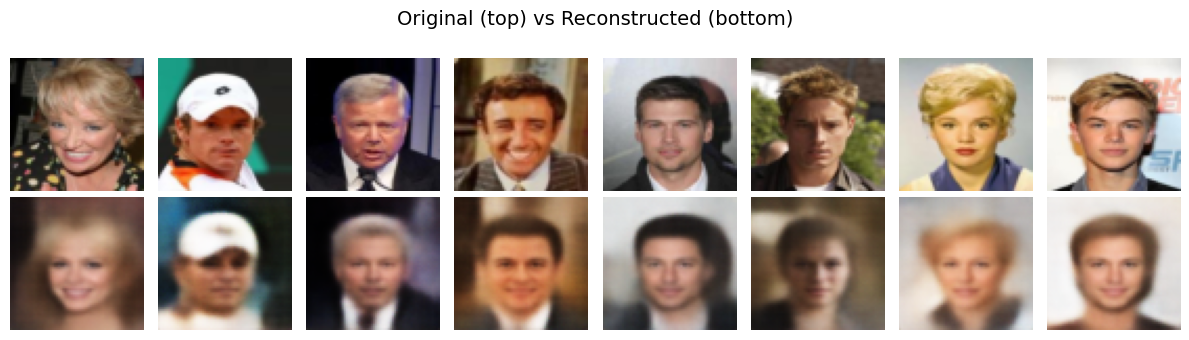

In [19]:
show_face_reconstructions(model, test_dataloader)

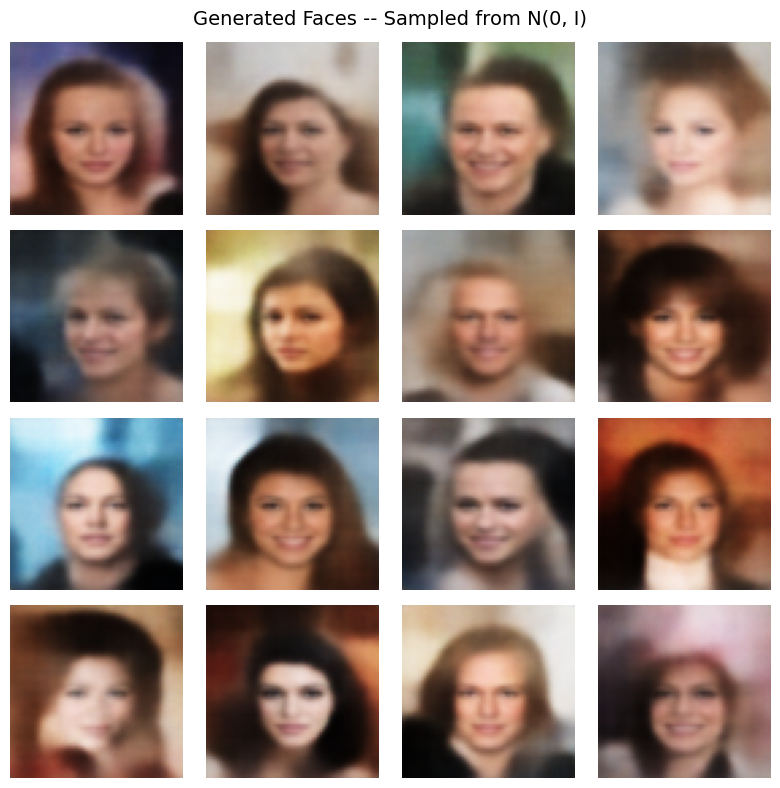

In [18]:
@torch.no_grad()
def generate_faces(model, n=16, latent_dim=128):
    model.eval()
    z = torch.randn(n, latent_dim).to(device)
    samples = model.decode(z)

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(samples[i].permute(1, 2, 0).cpu())
        ax.axis('off')
    plt.suptitle("Generated Faces -- Sampled from N(0, I)", fontsize=14)
    plt.tight_layout()
    plt.show()

generate_faces(model, n=16)

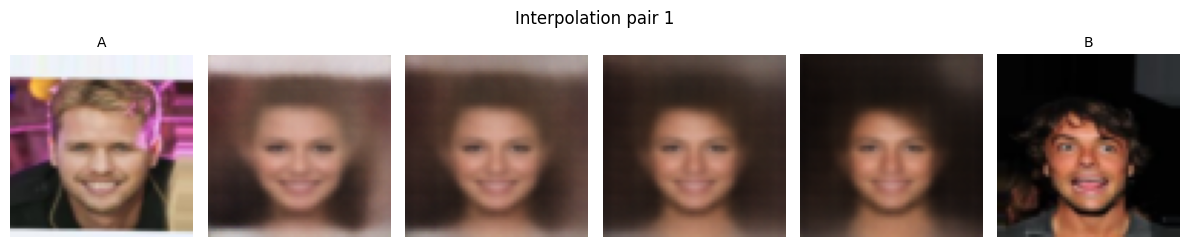

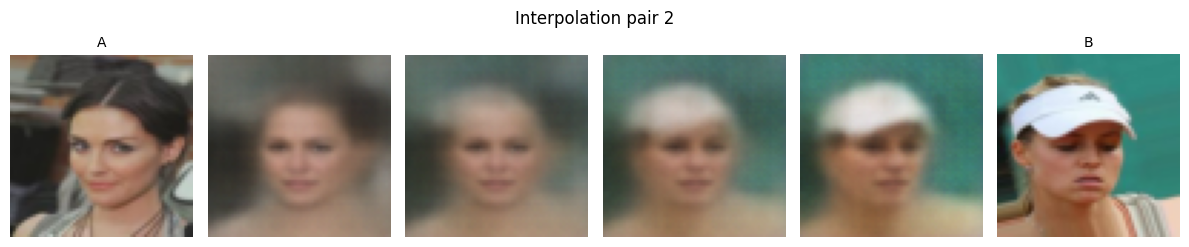

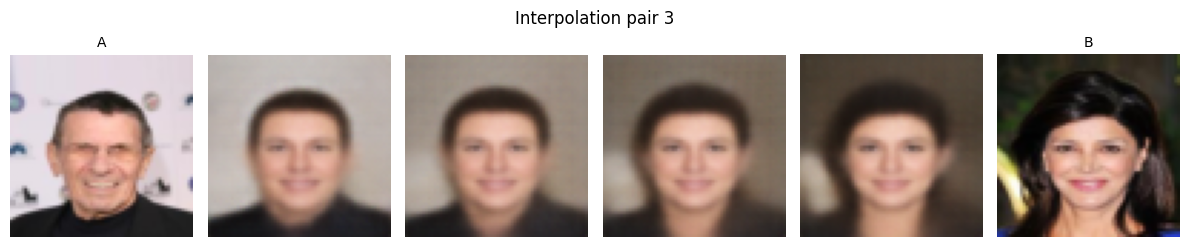

In [16]:
@torch.no_grad()
def latent_quality_check(model, loader, n_pairs=5):
    """Quick check: encode two faces, interpolate, see if transition is smooth."""
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device, non_blocking=True)

    for pair in range(n_pairs):
        img1 = x[pair*2:pair*2+1]
        img2 = x[pair*2+1:pair*2+2]

        mu1, _ = model.encode(img1)
        mu2, _ = model.encode(img2)

        fig, axes = plt.subplots(1, 6, figsize=(12, 2.5))
        axes[0].imshow(img1[0].permute(1,2,0).cpu())
        axes[0].set_title("A", fontsize=10)
        axes[0].axis('off')

        for i, alpha in enumerate([0.2, 0.4, 0.6, 0.8]):
            z_interp = (1 - alpha) * mu1 + alpha * mu2
            recon = model.decode(z_interp)
            axes[i+1].imshow(recon[0].permute(1,2,0).cpu())
            axes[i+1].axis('off')

        axes[5].imshow(img2[0].permute(1,2,0).cpu())
        axes[5].set_title("B", fontsize=10)
        axes[5].axis('off')

        plt.suptitle(f"Interpolation pair {pair+1}", fontsize=12)
        plt.tight_layout()
        plt.show()

latent_quality_check(model, test_dataloader, n_pairs=3)

In [15]:
# from sklearn.manifold import TSNE

# @torch.no_grad()
# def plot_latent_tsne(model, loader, n_samples=5000):
#     model.eval()
#     all_z = []
#     all_labels = []

#     for x, y in loader:
#         x = x.to(device)
#         mu, _ = model.encode(x)
#         all_z.append(mu.cpu())
#         all_labels.append(y)
#         if len(torch.cat(all_z)) >= n_samples:
#             break

#     z = torch.cat(all_z)[:n_samples].numpy()
#     labels = torch.cat(all_labels)[:n_samples].numpy()

#     # t-SNE to 2D
#     z_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(z)

#     fig, ax = plt.subplots(figsize=(8, 6))
#     scatter = ax.scatter(z_2d[:, 0], z_2d[:, 1], c=labels, cmap='tab10',
#                          s=5, alpha=0.7)
#     plt.colorbar(scatter, label="Digit Class")
#     ax.set_title("t-SNE of Latent Codes (colored by digit)", fontsize=14)
#     ax.set_xlabel("t-SNE 1")
#     ax.set_ylabel("t-SNE 2")
#     plt.tight_layout()
#     plt.show()

# plot_latent_tsne(model, test_dataloader)